# EV purchase propensity — three-model baseline

**Goal:** predict `P(Will_Buy_EV = Yes)` for every person in `test.csv`. This notebook trains and evaluates **XGBoost, CatBoost, and LightGBM** under one reproducible protocol. It produces separate probability files for each model.

**Data rule:** only `train.csv` is used to learn parameters and evaluate OOF metrics. `test.csv` is used only after model selection for final predictions. `sample_submission.csv` is not read or modified.

## 1. Imports, configuration, and reproducibility

The random seed, validation folds, and model settings are centralized here so experiments can be reproduced.

In [11]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.base import clone
from sklearn.calibration import CalibrationDisplay
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import average_precision_score, brier_score_loss, log_loss, roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier

warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_theme(style='whitegrid', context='notebook')
RANDOM_STATE = 42



## 2. Load train and test data

Paths work when the notebook is launched from either the project root or the `notebooks/` directory.

In [12]:
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_DIR = PROJECT_ROOT / 'data' / 'processed' / 'playground-series-s6e9'
TRAIN_PATH, TEST_PATH = DATA_DIR / 'train.csv', DATA_DIR / 'test.csv'
assert TRAIN_PATH.exists() and TEST_PATH.exists(), f'Missing train/test under {DATA_DIR}'

train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
TARGET, ID_COL = 'Will_Buy_EV', 'id'
RAW_FEATURES = [column for column in test.columns if column != ID_COL]

print(f'Train: {train.shape[0]:,} rows × {train.shape[1]} columns')
print(f'Test:  {test.shape[0]:,} rows × {test.shape[1]} columns')
display(train.head())


Train: 668,665 rows × 15 columns
Test:  286,571 rows × 14 columns


,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,No
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,No
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,Yes
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,No


## 3. Data-quality checks and target definition

`id` is an identifier, so it will never be passed into a model. Assertions make the expected schema and binary target explicit before any training starts.

In [13]:
assert set(RAW_FEATURES) == set(train.columns) - {ID_COL, TARGET}
assert train[ID_COL].is_unique and test[ID_COL].is_unique
assert set(train[TARGET].dropna().unique()) == {'Yes', 'No'}

quality = pd.DataFrame({
    'train_missing': train.isna().sum(),
    'test_missing': test.isna().sum(),
    'train_nunique': train.nunique(),
    'dtype': train.dtypes.astype(str),
})
display(quality)
print('Exact duplicate train rows:', train.duplicated().sum())

y = train[TARGET].eq('Yes').astype('int8')
print(f'Positive class rate: {y.mean():.2%}')


,train_missing,test_missing,train_nunique,dtype
Age,0,0.0,45,int64
Annual_Income_USD,0,0.0,13214,float64
Charging_Stations_Near_Home,0,0.0,15,int64
Charging_Stations_Near_Work,0,0.0,20,int64
City_Type,0,0.0,3,str
Current_Car_Type,0,0.0,4,str
Daily_Commute_km,0,0.0,805,float64
Environmental_Concern_Level,0,0.0,5,float64
Gender,0,0.0,3,str
Home_Charging_Possible,0,0.0,2,str


Exact duplicate train rows: 0
Positive class rate: 17.46%


## 4. Lightweight EDA

This is a descriptive check of class balance and the two variables expected to be influential. It does not establish causality.

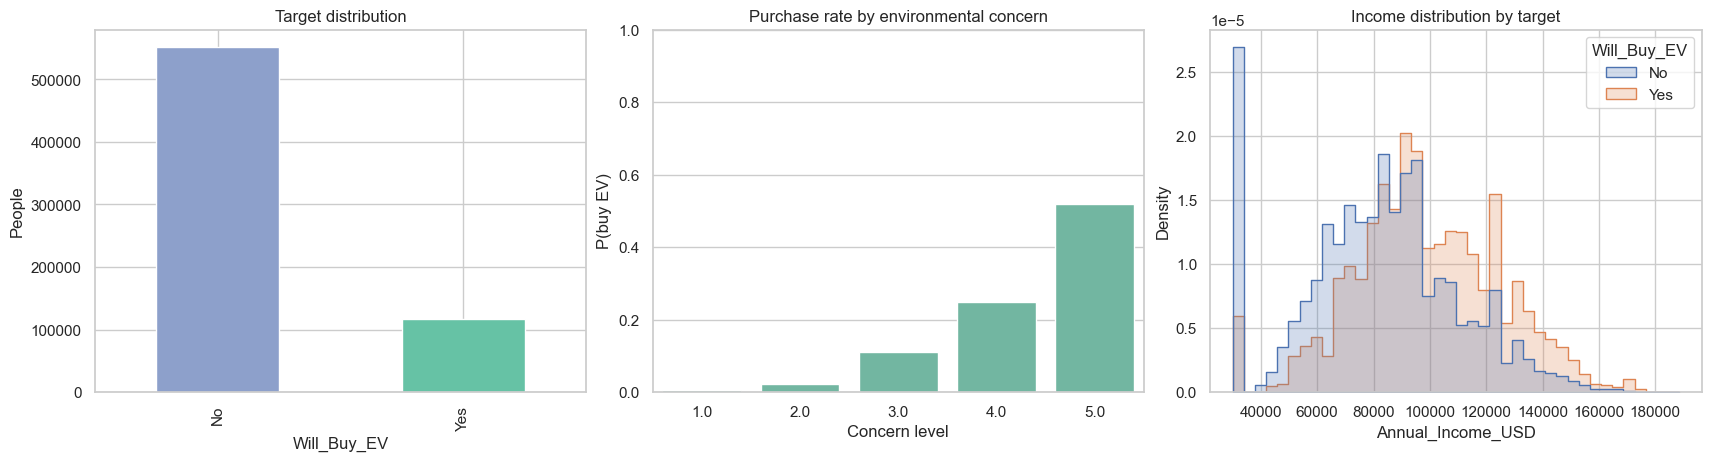

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5), constrained_layout=True)
train[TARGET].value_counts().reindex(['No', 'Yes']).plot.bar(ax=axes[0], color=['#8da0cb', '#66c2a5'])
axes[0].set(title='Target distribution', xlabel=TARGET, ylabel='People')

concern_rate = train.assign(_target=y).groupby('Environmental_Concern_Level', observed=False)['_target'].mean()
sns.barplot(x=concern_rate.index.astype(str), y=concern_rate.values, ax=axes[1], color='#66c2a5')
axes[1].set(title='Purchase rate by environmental concern', xlabel='Concern level', ylabel='P(buy EV)', ylim=(0, 1))

sns.histplot(data=train, x='Annual_Income_USD', hue=TARGET, stat='density', common_norm=False, bins=40, element='step', ax=axes[2])
axes[2].set_title('Income distribution by target')
plt.show()


## 5. Feature engineering

Features are deterministic transformations of information already available at prediction time. The same function is applied independently to train and test, avoiding target leakage. The engineered variables capture affordability, charging convenience, and plausible interactions between charging, concern, subsidy, and range anxiety.

In [15]:
def add_features(frame):
    out = frame.copy()
    cars = out['Number_of_Cars_Owned'].clip(lower=1)
    income = out['Annual_Income_USD'].clip(lower=1)
    out['Income_Per_Car_USD'] = out['Annual_Income_USD'] / cars
    out['Charging_Stations_Total'] = out['Charging_Stations_Near_Home'] + out['Charging_Stations_Near_Work']
    out['Charging_Stations_Work_Minus_Home'] = out['Charging_Stations_Near_Work'] - out['Charging_Stations_Near_Home']
    out['Commute_Per_10k_Income'] = out['Daily_Commute_km'] / income * 10_000
    out['Age_Band'] = pd.cut(out['Age'], bins=[0, 25, 35, 45, 55, 65, np.inf], labels=['<=25', '26-35', '36-45', '46-55', '56-65', '66+']).astype(str)
    out['Concern_x_Subsidy'] = out['Environmental_Concern_Level'].astype(str) + '_' + out['Subsidy_Available'].astype(str)
    out['HomeCharge_x_Anxiety'] = out['Home_Charging_Possible'].astype(str) + '_' + out['Range_Anxiety_Level'].astype(str)
    out['City_x_CurrentCar'] = out['City_Type'].astype(str) + '_' + out['Current_Car_Type'].astype(str)
    return out

X = add_features(train[RAW_FEATURES])
X_test = add_features(test[RAW_FEATURES])
assert X.columns.tolist() == X_test.columns.tolist()
FEATURES = X.columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_features = [column for column in FEATURES if column not in categorical_features]
print(f'Features after engineering: {len(FEATURES)} ({len(numeric_features)} numeric, {len(categorical_features)} categorical)')
display(X.head())


Features after engineering: 21 (11 numeric, 10 categorical)


C:\Users\Tony\AppData\Local\Temp\ipykernel_15692\2080070619.py:19: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()


,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,...,Subsidy_Available,Range_Anxiety_Level,Income_Per_Car_USD,Charging_Stations_Total,Charging_Stations_Work_Minus_Home,Commute_Per_10k_Income,Age_Band,Concern_x_Subsidy,HomeCharge_x_Anxiety,City_x_CurrentCar
0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,...,No,Low,46443.5,10,4,2.519190,66+,1.0_No,Yes_Low,Suburban_Sedan
1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,...,No,Low,30000.0,4,0,1.666667,36-45,4.0_No,Yes_Low,Rural_SUV
2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,...,Yes,Low,94389.0,23,7,3.898759,26-35,5.0_Yes,No_Low,Urban_Sedan
3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,...,No,Low,36790.0,15,3,3.220984,66+,3.0_No,Yes_Low,Suburban_Hatchback
4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,...,No,Low,57898.0,5,1,8.774051,46-55,3.0_No,Yes_Low,Suburban_Hatchback


## 6. Model-specific preprocessing and baseline configurations

- **CatBoost** receives categorical features natively.
- **LightGBM** receives pandas categorical dtypes with aligned categories across train/test.
- **XGBoost** receives one-hot encoded categoricals inside a fold-fitted pipeline.

No class weights are used because the primary output is a calibrated probability rather than a hard class decision.

In [16]:
# CatBoost data: categorical missing values must be explicit strings.
X_cat, X_test_cat = X.copy(), X_test.copy()
for column in categorical_features:
    X_cat[column] = X_cat[column].fillna('__MISSING__').astype(str)
    X_test_cat[column] = X_test_cat[column].fillna('__MISSING__').astype(str)
cat_feature_indices = [X_cat.columns.get_loc(column) for column in categorical_features]

# LightGBM data: align category vocabularies before each model sees them.
X_lgb, X_test_lgb = X.copy(), X_test.copy()
for column in categorical_features:
    categories = pd.Index(pd.concat([X_lgb[column], X_test_lgb[column]], ignore_index=True).fillna('__MISSING__').astype(str).unique())
    X_lgb[column] = pd.Categorical(X_lgb[column].fillna('__MISSING__').astype(str), categories=categories)
    X_test_lgb[column] = pd.Categorical(X_test_lgb[column].fillna('__MISSING__').astype(str), categories=categories)

xgb_preprocessor = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), numeric_features),
    ('cat', Pipeline([
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore')),
    ]), categorical_features),
])

def make_catboost():
    return CatBoostClassifier(loss_function='Logloss', eval_metric='AUC', iterations=500, learning_rate=0.05, depth=7, l2_leaf_reg=5.0, random_seed=RANDOM_STATE, verbose=False, thread_count=-1, allow_writing_files=False)

def make_lightgbm():
    return LGBMClassifier(objective='binary', n_estimators=500, learning_rate=0.05, num_leaves=31, max_depth=-1, min_child_samples=40, subsample=0.85, colsample_bytree=0.85, reg_lambda=5.0, random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1)

def make_xgboost():
    return XGBClassifier(objective='binary:logistic', eval_metric='logloss', n_estimators=500, max_depth=7, learning_rate=0.05, min_child_weight=5, subsample=0.85, colsample_bytree=0.85, reg_lambda=5.0, tree_method='hist', n_jobs=-1, random_state=RANDOM_STATE)


## 7. Train with 10-fold stratified out-of-fold validation

Each row receives one probability from a model that did not train on that row. This produces unbiased-in-practice OOF predictions for comparing ranking performance and probability calibration. The cell may take several minutes on CPU.

In [17]:
N_SPLITS = 10

cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
model_names = ['catboost', 'lightgbm', 'xgboost']
oof = {name: np.zeros(len(X), dtype=float) for name in model_names}
fold_rows = []

for fold, (fit_idx, valid_idx) in enumerate(cv.split(X, y), start=1):
    print(f'Fold {fold}/{N_SPLITS}')

    cat_model = make_catboost()
    cat_model.fit(X_cat.iloc[fit_idx], y.iloc[fit_idx], cat_features=cat_feature_indices)
    predictions = {'catboost': cat_model.predict_proba(X_cat.iloc[valid_idx])[:, 1]}

    lgb_model = make_lightgbm()
    lgb_model.fit(X_lgb.iloc[fit_idx], y.iloc[fit_idx], categorical_feature=categorical_features)
    predictions['lightgbm'] = lgb_model.predict_proba(X_lgb.iloc[valid_idx])[:, 1]

    xgb_model = Pipeline([('prep', clone(xgb_preprocessor)), ('model', make_xgboost())])
    xgb_model.fit(X.iloc[fit_idx], y.iloc[fit_idx])
    predictions['xgboost'] = xgb_model.predict_proba(X.iloc[valid_idx])[:, 1]

    for name, probability in predictions.items():
        oof[name][valid_idx] = probability
        fold_rows.append({'fold': fold, 'model': name, 'roc_auc': roc_auc_score(y.iloc[valid_idx], probability), 'log_loss': log_loss(y.iloc[valid_idx], probability)})


Fold 1/10
Fold 2/10
Fold 3/10
Fold 4/10
Fold 5/10
Fold 6/10
Fold 7/10
Fold 8/10
Fold 9/10
Fold 10/10


## 8. Evaluate OOF results and inspect calibration

ROC-AUC evaluates ranking. Average precision is useful with class imbalance. Log loss and Brier score assess probability quality; lower is better for the latter two.

,model,roc_auc,average_precision,log_loss,brier_score
0,lightgbm,0.94178,0.75619,0.22656,0.07121
1,xgboost,0.94170,0.75630,0.22666,0.07122
2,catboost,0.94133,0.75421,0.22739,0.07153


roc_auc          log_loss         
             mean      std     mean      std
model                                       
catboost  0.94133  0.00099  0.22739  0.00172
lightgbm  0.94179  0.00102  0.22656  0.00177
xgboost   0.94171  0.00101  0.22666  0.00176

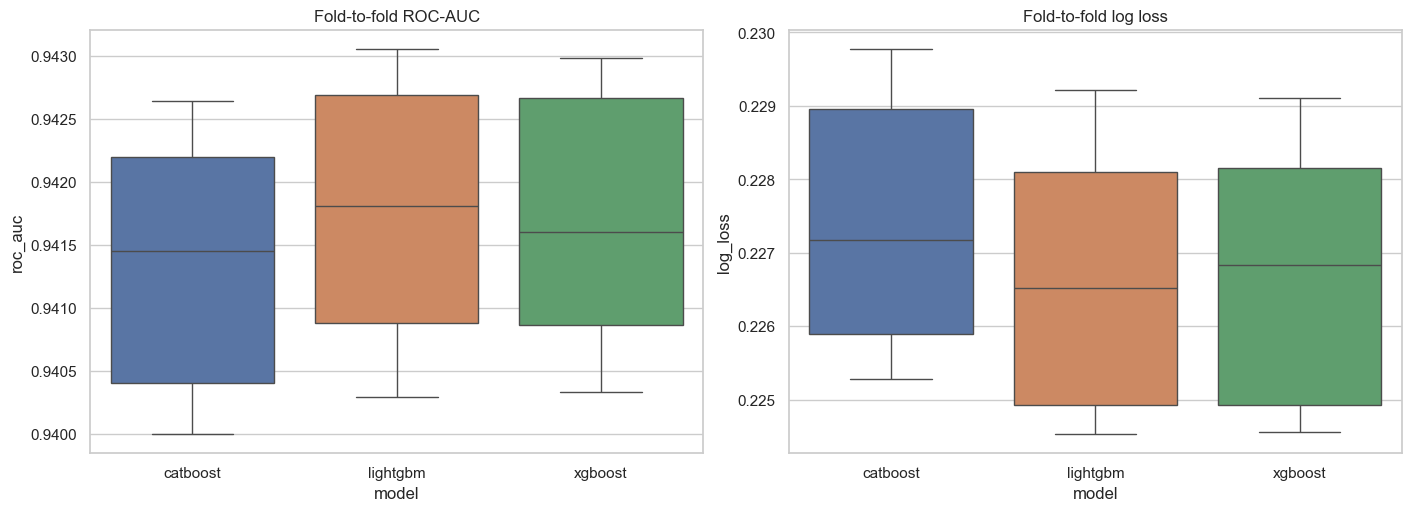

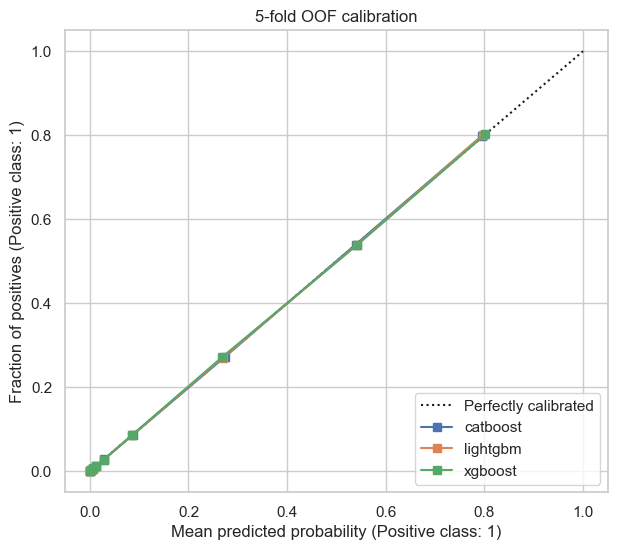

Best model by OOF ROC-AUC then log loss: lightgbm


In [20]:
metrics = pd.DataFrame([
    {'model': name, 'roc_auc': roc_auc_score(y, probability), 'average_precision': average_precision_score(y, probability), 'log_loss': log_loss(y, probability), 'brier_score': brier_score_loss(y, probability)}
    for name, probability in oof.items()
]).sort_values(['roc_auc', 'log_loss'], ascending=[False, True]).reset_index(drop=True)
fold_metrics = pd.DataFrame(fold_rows)
display(metrics.style.format({'roc_auc': '{:.5f}', 'average_precision': '{:.5f}', 'log_loss': '{:.5f}', 'brier_score': '{:.5f}'}))
display(fold_metrics.groupby('model')[['roc_auc', 'log_loss']].agg(['mean', 'std']).round(5))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
sns.boxplot(data=fold_metrics, x='model', y='roc_auc', hue='model', legend=False, ax=axes[0])
axes[0].set_title('Fold-to-fold ROC-AUC')
sns.boxplot(data=fold_metrics, x='model', y='log_loss', hue='model', legend=False, ax=axes[1])
axes[1].set_title('Fold-to-fold log loss')
plt.show()

fig, ax = plt.subplots(figsize=(7, 6))
for name, probability in oof.items():
    CalibrationDisplay.from_predictions(y, probability, n_bins=10, strategy='quantile', name=name, ax=ax)
ax.set_title('5-fold OOF calibration')
plt.show()

best_name = metrics.loc[0, 'model']
print(f'Best model by OOF ROC-AUC then log loss: {best_name}')


## 9. Refit on all training data and export outputs

After OOF evaluation, each model is refit on all labelled rows and generates a separate test-set probability file. This preserves the ability to compare or submit models independently.

In [21]:
# CatBoost final fit and output
cat_final = make_catboost()
cat_final.fit(X_cat, y, cat_features=cat_feature_indices)

# LightGBM final fit and output
lgb_final = make_lightgbm()
lgb_final.fit(X_lgb, y, categorical_feature=categorical_features)

# XGBoost final fit and output
xgb_final = Pipeline([('prep', clone(xgb_preprocessor)), ('model', make_xgboost())])
xgb_final.fit(X, y)

test_probabilities = {
    'catboost': cat_final.predict_proba(X_test_cat)[:, 1],
    'lightgbm': lgb_final.predict_proba(X_test_lgb)[:, 1],
    'xgboost': xgb_final.predict_proba(X_test)[:, 1],
}

output_paths = {}
for name, probability in test_probabilities.items():
    submission = pd.DataFrame({ID_COL: test[ID_COL], TARGET: probability})
    assert submission[ID_COL].equals(test[ID_COL])
    assert submission[TARGET].between(0, 1).all() and not submission.isna().any().any()
    path = DATA_DIR / f'submission_baseline_{name}.csv'
    submission.to_csv(path, index=False)
    output_paths[name] = path
    print(f'{name}: saved {path.name}; mean probability = {submission[TARGET].mean():.4f}')


catboost: saved submission_baseline_catboost.csv; mean probability = 0.1747
lightgbm: saved submission_baseline_lightgbm.csv; mean probability = 0.1747
xgboost: saved submission_baseline_xgboost.csv; mean probability = 0.1746


## 10. Recommended next iteration

Select a champion based on stable OOF metrics rather than test predictions. Then tune only that model with cross-validation, review subgroup calibration, and test probability blends from OOF predictions before producing a final submission.